In [2]:
import polars as pl
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


Matplotlib is building the font cache; this may take a moment.


O objetivo desta etapa é compreender as características estatísticas do conjunto de dados, identificar padrões relevantes para a modelagem e avaliar a relação entre as variáveis preditoras e a variável alvo (target). Como o objetivo do projeto é prever a direção futura do preço em um horizonte de 15 minutos, a análise será direcionada para identificar possíveis sinais preditivos presentes nas variáveis de microestrutura de mercado.

In [5]:
df = pl.read_parquet(
    "features/ml_features_1m_v2.parquet"
)

print(df.shape)
df.head()

(5587547, 16)


market_id,minute_bar,close_mid,mean_spread,close_spread,bar_volatility,total_volume,buy_volume,sell_volume,trade_count,order_flow_imbalance,target,return_1m,bid_depth,ask_depth,depth_imbalance
str,"datetime[μs, UTC]",f32,f32,f32,f32,f32,f32,f32,u32,f32,i8,f32,f64,f64,f64
"""0x0007deb167d0bb816e2e847a1543…",2026-03-06 00:00:00 UTC,0.285,0.45375,0.45,0.005,0.0,0.0,0.0,0,0.0,0,0.017857,287.79,3845.07,-0.860731
"""0x0007deb167d0bb816e2e847a1543…",2026-03-06 00:01:00 UTC,0.285,0.45,0.45,0.0,0.0,0.0,0.0,0,0.0,0,0.0,287.79,3845.07,-0.860731
"""0x0007deb167d0bb816e2e847a1543…",2026-03-06 00:02:00 UTC,0.29,0.443333,0.44,0.005,0.0,0.0,0.0,0,0.0,0,0.017544,287.79,3845.07,-0.860731
"""0x0007deb167d0bb816e2e847a1543…",2026-03-06 00:03:00 UTC,0.29,0.44,0.44,0.0,0.0,0.0,0.0,0,0.0,0,0.0,287.79,3845.07,-0.860731
"""0x0007deb167d0bb816e2e847a1543…",2026-03-06 00:04:00 UTC,0.29,0.44,0.44,0.0,0.0,0.0,0.0,0,0.0,0,0.0,366.8,8838.88,-0.92031


# Quantas observações e mercados existem?

In [9]:
print(f"Linhas: {df.height:,}")
print(f"Colunas: {df.width}")

df.select(
    pl.col("market_id").n_unique().alias("mercados_unicos")
)

Linhas: 5,587,547
Colunas: 16


mercados_unicos
u32
4710


# Qual o período coberto pelos dados?

In [14]:
# Veificar datas
# Objetivo: Identificar as datas de início e fim do intervalo para planejar a divisão cronológica de treino e teste.
# Resultado: O subconjunto de dados cobre exatamente 6 dias completos, de 06/03/2026 a 11/03/2026.
# Implicação: Ideal para validação inicial (ex: usar os primeiros 4 dias para treino e os 2 últimos para teste).
df.select(
    pl.min("minute_bar").alias("inicio"),
    pl.max("minute_bar").alias("fim")
)

inicio,fim
"datetime[μs, UTC]","datetime[μs, UTC]"
2026-03-06 00:00:00 UTC,2026-03-11 23:59:00 UTC


# Como os dados estão distribuídos ao longo do tempo?

In [10]:
(
    df.select(
        pl.col("minute_bar").dt.date().alias("date")
    )
    .group_by("date")
    .len()
    .sort("date")
)

date,len
date,u32
2026-03-06,1631467
2026-03-07,1570162
2026-03-08,1306097
2026-03-09,440677
2026-03-10,530106
2026-03-11,109038


O volume diário começa alto (~1.6M de linhas no dia 06) e sofre uma redução acentuada a partir do dia 09, atingindo o mínimo no dia 11 (~109k). Essa assimetria indica que mercados foram fechados/resolvidos ou houve uma mudança na coleta. Precisamos garantir que os dias de teste (ex: dias 10 e 11) ainda contenham os mercados principais para uma validação justa.

# Análise da quantidade de observações por mercado.

In [ ]:
print(df.group_by("market_id").len().describe())
df.group_by("market_id").len().sort("len").head()


shape: (9, 3)
┌────────────┬─────────────────────────────────┬─────────────┐
│ statistic  ┆ market_id                       ┆ len         │
│ ---        ┆ ---                             ┆ ---         │
│ str        ┆ str                             ┆ f64         │
╞════════════╪═════════════════════════════════╪═════════════╡
│ count      ┆ 4710                            ┆ 4710.0      │
│ null_count ┆ 0                               ┆ 0.0         │
│ mean       ┆ null                            ┆ 1186.315711 │
│ std        ┆ null                            ┆ 1314.819778 │
│ min        ┆ 0x0007deb167d0bb816e2e847a1543… ┆ 1.0         │
│ 25%        ┆ null                            ┆ 296.0       │
│ 50%        ┆ null                            ┆ 662.0       │
│ 75%        ┆ null                            ┆ 1588.0      │
│ max        ┆ 0xfff145c6201796960cac69aea3f6… ┆ 8221.0      │
└────────────┴─────────────────────────────────┴─────────────┘


market_id,len
str,u32
"""0xaf617e83074e3536fa1b86b1190b…",1
"""0x563ecbc4fcc34f60103e9c5b3354…",3
"""0xb0ea878453eb9c7a835e6820fd35…",3
"""0xec363de4b390604e844387471ab5…",3
"""0xe790b91b38c4d42ecb3e66af723f…",4


Existe grande heterogeneidade entre os mercados. Enquanto alguns possuem apenas 1 observação, outros chegam a mais de 8.000 observações. A mediana é de 662 registros por mercado.  A presença de mercados com histórico muito reduzido sugere a necessidade de avaliar critérios mínimos de observações durante a etapa de modelagem. Será investigado posteriormente o impacto de filtros como len >= 1440 (1 dia completo de negociação) na quantidade total de dados disponíveis.

# Como as variáveis se comportam em termos de média, dispersão e amplitude?

In [11]:
features = [
    "close_mid",
    "mean_spread",
    "close_spread",
    "bar_volatility",
    "total_volume",
    "buy_volume",
    "sell_volume",
    "trade_count",
    "order_flow_imbalance",
    "return_1m",
    "bid_depth",
    "ask_depth",
    "depth_imbalance"
]

df.select(features).describe()

statistic,close_mid,mean_spread,close_spread,bar_volatility,total_volume,buy_volume,sell_volume,trade_count,order_flow_imbalance,return_1m,bid_depth,ask_depth,depth_imbalance
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6,5.587547e6
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.264384,0.106947,0.105988,0.005248,16.70355,13.900503,2.803048,0.105569,11.097455,0.358244,60529.263125,199718.031162,-0.337332
"""std""",0.280244,0.227499,0.227542,0.031491,862.310974,808.899719,270.595612,1.097412,843.505432,18.620455,144176.553546,1.4187e6,0.557125
"""min""",0.0005,0.000667,0.001,0.0,0.0,0.0,0.0,0.0,-344164.84375,-0.999,0.0,0.0,-1.0
"""25%""",0.0155,0.005,0.005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,486.78,3550.52,-0.843943
"""50%""",0.205,0.015,0.015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2845.32,17553.28,-0.424224
"""75%""",0.435,0.05,0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22510.5,90904.98,0.000912
"""max""",0.9995,1.0,1.0,0.9855,680889.0,680884.0,354123.78125,443.0,680879.0,998.999939,5.0261e6,2.1935e7,1.0


# Distribuição do Target

## O problema é balanceado?

In [13]:
print(df.group_by("target").len())

df.group_by("target").len().with_columns(
    (
        pl.col("len") /
        pl.col("len").sum()
    ).alias("proportion")
)

shape: (2, 2)
┌────────┬─────────┐
│ target ┆ len     │
│ ---    ┆ ---     │
│ i8     ┆ u32     │
╞════════╪═════════╡
│ 1      ┆ 1489089 │
│ 0      ┆ 4098458 │
└────────┴─────────┘


target,len,proportion
i8,u32,f64
0,4098458,0.733499
1,1489089,0.266501


A variável alvo apresenta aproximadamente 73% de exemplos da classe 0 e 27% da classe 1, caracterizando um problema desbalanceado.

# Distribuição das Principais Features

In [14]:
df.filter(
    pl.col("order_flow_imbalance") > 1000
).select(
    [
        "buy_volume",
        "sell_volume",
        "total_volume",
        "order_flow_imbalance"
    ]
).head(20)

buy_volume,sell_volume,total_volume,order_flow_imbalance
f32,f32,f32,f32
1110.587891,6.05,1116.637939,1104.537842
1709.925781,0.0,1709.925781,1709.925781
4922.630859,0.0,4922.630859,4922.630859
2623.600342,0.0,2623.600342,2623.600342
1043.23938,0.0,1043.23938,1043.23938
…,…,…,…
2292.519287,0.0,2292.519287,2292.519287
1923.076904,0.0,1923.076904,1923.076904
10217.172852,0.0,10217.172852,10217.172852


A inspeção dos registros revelou que a variável order_flow_imbalance corresponde à diferença bruta entre volume comprador e volume vendedor (buy_volume - sell_volume) e não à versão normalizada descrita na documentação do dataset. Para consertar isso vamos criar uma feature que segue a fórmula (buy_volume - sell_volume)/total_volume

In [17]:
df_eda = df.with_columns(
    pl.when(pl.col("total_volume") > 0)
    .then(
        (pl.col("buy_volume") - pl.col("sell_volume"))
        / pl.col("total_volume")
    )
    .otherwise(0)
    .alias("ofi_normalized")
)

df_eda.select(
    [
        pl.col("ofi_normalized").min().alias("min"),
        pl.col("ofi_normalized").max().alias("max"),
        pl.col("ofi_normalized").mean().alias("mean")
    ]
)


min,max,mean
f32,f32,f32
-1.0,1.0,0.026979


<Figure size 800x400 with 0 Axes>

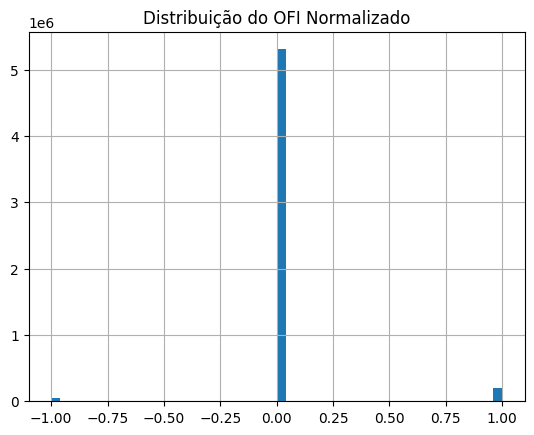

In [18]:
plt.figure(figsize=(8,4))

df_eda.select("ofi_normalized") \
      .to_pandas() \
      .hist(bins=50)

plt.title("Distribuição do OFI Normalizado")
plt.show()

O histograma do OFI comprova que a microestrutura do Polymarket é caracterizada por longos períodos de latência/equilíbrio (concentração massiva em 0.0), intercalados por choques de liquidez unilaterais de alta intensidade (picos em -1.0 e 1.0). Esse comportamento de caudas pesadas e alta concentração central valida a necessidade de algoritmos não-lineares (como árvores de decisão) para capturar os momentos de virada de tendência do mercado.

Um minuto sem negociações significa:
- Baixa liquidez
- Baixo interesse
- Pouca atividade

O eixo horizontal (X) mostra os valores assumidos por order_flow_imbalance. O eixo vertical (Y) mostra a contagem de linhas (frequência)

<Figure size 800x400 with 0 Axes>

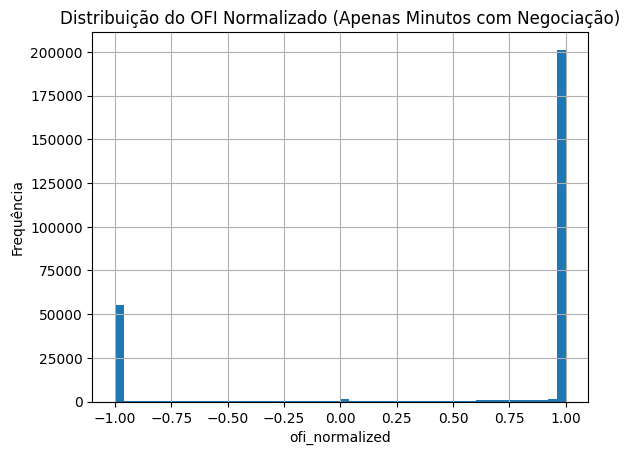

In [39]:
plt.figure(figsize=(8,4))

df_eda.filter(
    pl.col("total_volume") > 0
).select(
    "ofi_normalized"
).to_pandas().hist(
    bins=50
)

plt.title("Distribuição do OFI Normalizado (Apenas Minutos com Negociação)")
plt.xlabel("ofi_normalized")
plt.ylabel("Frequência")
plt.show()

<Figure size 800x400 with 0 Axes>

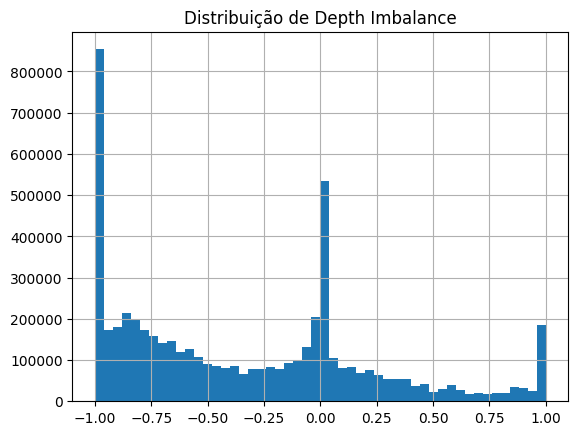

In [16]:
plt.figure(figsize=(8,4))

df.select(
    "depth_imbalance"
).to_pandas().hist(
    bins=50
)

plt.title("Distribuição de Depth Imbalance")
plt.show()

1. Há um pico massivo perto de -1.0 (com mais de 800.000 ocorrências).O que significa: Para o cálculo resultar em $-1.0$, o bid_depth (compradores) é praticamente zero em comparação com o ask_depth (vendedores). O livro está completamente inundado de ordens de venda.

Interpretação Econômica: Muitos mercados de previsão sofrem com falta de liquidez bilateral ou chegam a um ponto onde o resultado do evento fica muito óbvio (ex: um contrato de "SIM" que passa a valer 0.02 dólares porque o evento quase certamente não vai acontecer). Nesses cenários, os compradores desaparecem e sobram apenas ordens de venda massivas empilhadas no livro.


2. Repare que o lado esquerdo do gráfico é visivelmente mais alto e volumoso do que o lado direito.

O que significa: Existe uma tendência geral, na média histórica desses dados, de o livro ter mais profundidade de venda (ask_depth) do que de compra (bid_depth).

Interpretação Econômica: Isso indica que muitos criadores de mercado (market makers) ou apostadores preferem deixar suas posições limitadas de vendas abertas, gerando uma pressão vendedora estrutural na base. No Polymarket, os robôs preferem operar como grandes lojas de departamentos (vendedores) do que como clientes (compradores). Eles enchem as prateleiras com ordens de venda pendentes porque é estatisticamente mais seguro coletar os centavos dos apostadores do que tentar adivinhar o futuro comprando contratos. É por isso que o seu gráfico de depth_imbalance pende tanto para o lado negativo (venda)!

Outro motivo: Pense em como as pessoas apostam. Se você comprou um contrato por 20 centavos achando que um evento ia acontecer, e o evento começa a dar errado, você não consegue simplesmente clicar em um botão e sumir com o contrato. Você é obrigado a colocá-lo à venda no livro de ofertas por um preço baixo (tipo 15 centavos) e ficar esperando sentada até que algum corajoso apareça para comprar.

Como muita gente desiste das apostas ou tenta "mudar de lado", o livro de ofertas vira um grande estoque parado de pessoas tentando se livrar de contratos antigos

3. Existe um pico isolado exatamente em 0.0 (com cerca de 500.000 ocorrências).

O que significa: Significa que bid_depth é exatamente igual a ask_depth.

Interpretação Econômica: São os momentos de equilíbrio perfeito ou, mais provável no Polymarket, momentos em que robôs de liquidez (algoritmos de arbitragem) colocam ordens perfeitamente espelhadas de compra e venda com tamanhos idênticos em mercados eficientes.

4. No extremo direito, há um pico modesto perto de +1.0.O que significa: O livro ficou sem nenhuma ordem de venda significativa e foi tomado por intenções de compra.Interpretação Econômica: Representa momentos de forte convicção de alta de um contrato, mas que ocorre com muito menos frequência do que o colapso para o lado vendedor (por isso o pico do $+1.0$ é bem menor do que o do $-1.0$).

<Figure size 800x400 with 0 Axes>

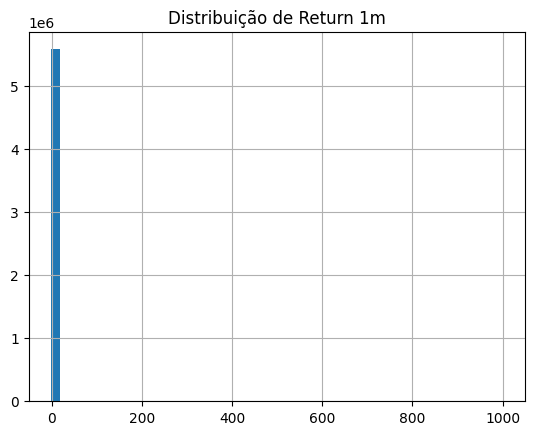

In [17]:
plt.figure(figsize=(8,4))

df.select(
    "return_1m"
).to_pandas().hist(
    bins=50
)

plt.title("Distribuição de Return 1m")
plt.show()

O Return 1m mede o quanto o preço de um contrato mudou de um minuto para o outro. Na maior parte dos minutos, os preços no Polymarket ficam completamente parados. Como não há mudança, o retorno é exatamente $0$. Na linha de baixo vemos que aproxidamente 95% do dataset tem a variável total_voluma = 0. Se não teve negociação, o preço não mudou. 

In [29]:
# Aqui vemos quantas linhas e a proporção de linhas onde o volume total é zero, o que pode indicar períodos sem negociação ou dados faltantes.
zero_volume = df.filter(
    pl.col("total_volume") == 0
).height

print(zero_volume)
print(100 * zero_volume / df.height)

5306616
94.97219441733554


Essa questão do total_voluma == 0 também pode implicar no gráfico de OFI

In [34]:
# Média das Features por classe do target 

df_eda = df.with_columns(
    pl.when(pl.col("total_volume") > 0)
    .then(
        (pl.col("buy_volume") - pl.col("sell_volume"))
        / pl.col("total_volume")
    )
    .otherwise(0)
    .alias("ofi_normalized")
)

df_eda.group_by("target").agg(
    [
        pl.mean("total_volume").alias("avg_volume"),
        pl.mean("trade_count").alias("avg_trades"),
        pl.mean("ofi_normalized").alias("avg_ofi_normalized")
    ]
)

target,avg_volume,avg_trades,avg_ofi_normalized
i8,f32,f64,f32
0,14.754079,0.098188,0.026861
1,22.069132,0.125884,0.027302


Sobre avg_volume:
- Os minutos que antecedem a alta (target 1) possuem, em média 50% mais volume negociado (22.07 - 14.75)/14.75

Sobre o avg_trades:
- Os períodos que antecedem uma alta, apresentam maior quantidade de negociações 

In [35]:
df.filter(
    pl.col("total_volume") > 0
).group_by("target").len()

target,len
i8,u32
0,200931
1,80000


Mesmo removendo 95% das linhas, o comportamento de desbalanceamento continua parecido. As porcentagens continuam parecidas.


<Figure size 800x400 with 0 Axes>

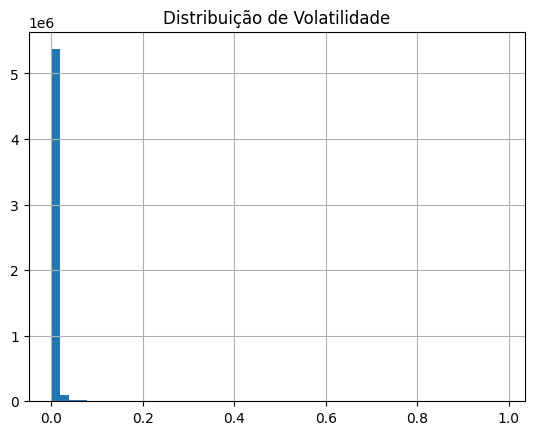

In [18]:
plt.figure(figsize=(8,4))

df.select(
    "bar_volatility"
).to_pandas().hist(
    bins=50
)

plt.title("Distribuição de Volatilidade")
plt.show()

A volatilidade mede a intensidade das oscilações de preço dentro de um único minuto.

Um valor próximo de 0.0 significa que o preço ficou praticamente congelado, sem se mexer durante aquele minuto.

Um valor mais alto (andando para a direita no gráfico) significa que o preço variou de forma frenética e instável naquele minuto (sobe e desce muito rápido).

O histograma apresenta uma agulha gigantesca (mais de 5 milhões de minutos) espremida colada no 0.0.

Isso nos revela duas características fundamentais da microestrutura do Polymarket:

Predomínio de Estabilidade Absoluta: Na imensa maioria do tempo, o preço dos contratos não sofre nenhuma variação brusca dentro do mesmo minuto. O mercado passa a maior parte do dia calmo, plano e sem oscilações.

Caudas Longas de Eventos Raros: Repare que existe um minúsculo "tapete" de dados que se estende perto do zero, mas o gráfico vai até o 1.0 completamente vazio. Isso mostra que minutos com volatilidade média ou alta são raríssimos.

<Figure size 800x400 with 0 Axes>

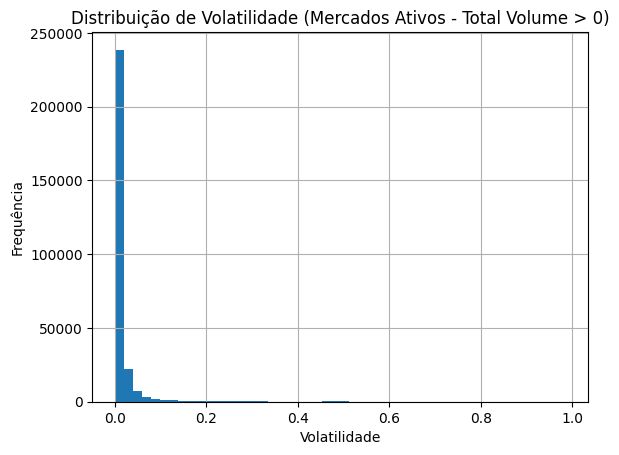

In [37]:
df_active = df.filter(
    pl.col("total_volume") > 0
)

plt.figure(figsize=(8,4))

df_active.select(
    "bar_volatility"
).to_pandas().hist(
    bins=50
)

plt.title("Distribuição de Volatilidade (Mercados Ativos - Total Volume > 0)")
plt.xlabel("Volatilidade")
plt.ylabel("Frequência")
plt.show()

# Comparação das Features por Classe

### Mercados que sobem possuem características diferentes dos que não sobem?

In [46]:
df_eda = df.with_columns(
    pl.when(pl.col("total_volume") > 0)
    .then(
        (pl.col("buy_volume") - pl.col("sell_volume"))
        / pl.col("total_volume")
    )
    .otherwise(0)
    .alias("ofi_normalized")
)

df_eda.group_by("target").agg(
    [
        pl.col("ofi_normalized").mean(),
        pl.col("depth_imbalance").mean(),
        pl.col("return_1m").mean(),
        pl.col("bar_volatility").mean(),
        pl.col("total_volume").mean()
    ]
)

target,ofi_normalized,depth_imbalance,return_1m,bar_volatility,total_volume
i8,f32,f64,f32,f32,f32
0,0.026861,-0.50996,0.487762,0.004418,14.754079
1,0.027302,0.137799,0.001769,0.007531,22.069132


Ao agrupar as médias das features pelo valor do `target`, conseguimos validar nossas hipóteses macroeconômicas:

1. **Confirmação do Depth Imbalance:** Quando o target é positivo (1), o `depth_imbalance` médio é positivo (0.13), indicando acúmulo de demanda compradora. Quando o target é zero (0), o imbalance cai drasticamente para -0.50, confirmando a pressão vendedora estrutural.
2. **Validação do Volume:** Períodos que antecedem altas futuras (target=1) apresentam um volume negociado significativamente maior (22.06 vs 14.75), agindo como o "combustível" da tendência.
3. **Plano de Ação (Data Cleaning):** Identificamos duas anomalias matemáticas: as médias do `order_flow_imbalance` estão acima do limite teórico de 1.0, e a média do `return_1m` está distorcida por outliers. O grupo irá realizar o tratamento e a filtragem dessas variáveis antes de alimentar os modelos de classificação.
4. **Equilíbrio no Fluxo (`ofi_normalized`):** Ambas as médias estão próximas de zero, indicando que o mercado passa a maior parte do tempo com forças de agressão de compra e venda equilibradas. No entanto, há um aumento marginal no fluxo comprador (de 0.026 para 0.027) nos minutos que antecedem uma alta do ativo (`target = 1`).
5. **Poder Preditivo do Livro (`depth_imbalance`):** O desequilíbrio de ordens paradas continua sendo o sinal mais forte do dataset. Quando o preço vai subir, há um saldo positivo de compradores na fila (+0.13). Quando o preço tende a cair ou estagnar, o livro fica severamente carregado de vendedores (-0.50).

In [45]:
df_eda = df.with_columns(
    pl.when(pl.col("total_volume") > 0)
    .then(
        (pl.col("buy_volume") - pl.col("sell_volume"))
        / pl.col("total_volume")
    )
    .otherwise(0)
    .alias("ofi_normalized")
)


df_eda.group_by("target").agg(
    [
        pl.col("ofi_normalized").median(),
        pl.col("depth_imbalance").median(),
        pl.col("return_1m").median(),
        pl.col("bar_volatility").median()
    ]
)

target,ofi_normalized,depth_imbalance,return_1m,bar_volatility
i8,f32,f64,f32,f32
0,0.0,-0.649152,0.0,0.0
1,0.0,0.013235,0.0,0.0


1. **Predomínio da Inércia:** As medianas cravadas em `0.0` para as variáveis de Fluxo, Retorno e Volatilidade confirmam estatisticamente o cenário de "agulha" visto nos histogramas. Na maior parte do tempo, os mercados operam em regime de baixa atividade e estabilidade de preços.
2. **Robustez do Depth Imbalance:** A mediana do `depth_imbalance` provou ser imune aos ruídos da base, mantendo uma separação clara entre os cenários. Em regime normal de não-alta (target=0), o livro exibe forte assimetria vendedora (-0.64). Nos momentos que antecedem a valorização do contrato (target=1), o livro sofre uma inversão estrutural, tornando-se comprador (+0.01).
3. **Comportamento dos Extremos no OFI:** O histograma do OFI Normalizado revela picos concentrados em -1.0, 0.0 e 1.0. Isso evidencia a dinâmica de microestrutura do Polymarket, onde minutos de baixa liquidez registram agressões isoladas e unilaterais, fazendo o indicador tocar nos limites teóricos da fórmula.

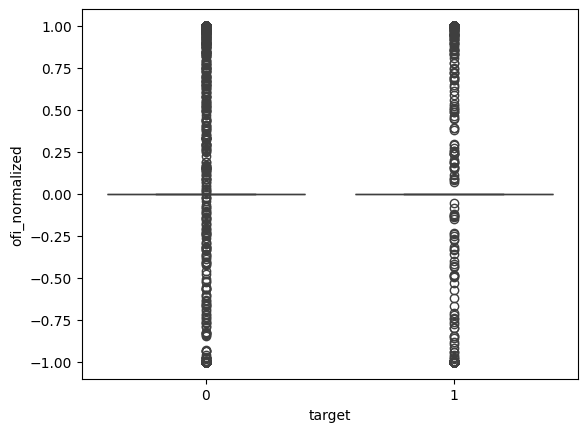

In [48]:
df_eda = df.with_columns(
    pl.when(pl.col("total_volume") > 0)
    .then(
        (pl.col("buy_volume") - pl.col("sell_volume"))
        / pl.col("total_volume")
    )
    .otherwise(0)
    .alias("ofi_normalized")
)

sample = (
    df_eda.select(
        ["target", "ofi_normalized"],      
    )
    .sample(
        n=100000,
        seed=42
    )
    .to_pandas()
)

sns.boxplot(
    data=sample,
    x="target",
    y="ofi_normalized"
)

plt.show()

O cruzamento visual entre o fluxo de ordens normalizado (`ofi_normalized`) e a variável preditiva (`target`) através do boxplot confirma as características analíticas da base:

1. **Achatamento Central da Distribuição:** A região interquartil (caixa do boxplot) apresenta-se totalmente comprimida na linha do zero para ambos os targets (`0` e `1`). Isto evidencia a alta concentração de minutos com atividade perfeitamente equilibrada ou nula no mercado.
2. **Densidade de Outliers de Liquidez:** As caudas verticais compostas por outliers estendem-se de forma simétrica até os limites teóricos de `-1.0` (agressão vendedora máxima) e `+1.0` (agressão compradora máxima). 
3. **Padrão de Distribuição Similar:** O formato visual idêntico das duas distribuições reitera que o fluxo de ordens de 1 minuto, isoladamente, possui comportamento estatístico muito similar entre os regimes de alta e baixa do target, demandando uma atuação conjunta com a variável `depth_imbalance` na modelagem.

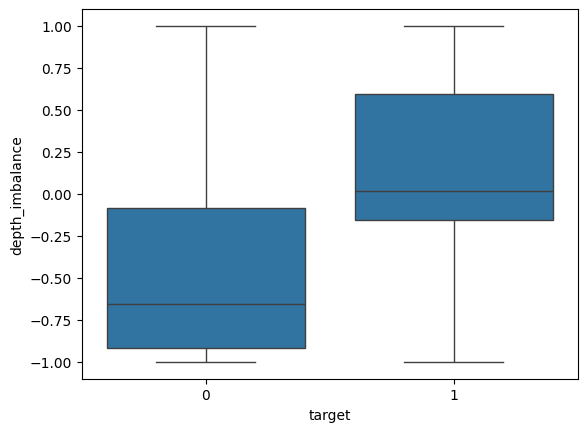

In [30]:
sample = (
    df.select(
        ["target", "depth_imbalance"],      
    )
    .sample(
        n=100000,
        seed=42
    )
    .to_pandas()
)

sns.boxplot(
    data=sample,
    x="target",
    y="depth_imbalance"
)

plt.show()

O cruzamento do desequilíbrio de profundidade do livro (`depth_imbalance`) com o `target` através do boxplot revela o maior poder preditivo (feature importance) do ecossistema de microestrutura analisado:

1. **Separação Clara de Regimes:** Diferente de outras variáveis, os quartis do `depth_imbalance` mudam drasticamente de patamar físico entre os alvos. O regime de target=0 é caracterizado por um viés vendedor severo (mediana próxima a -0.65), enquanto o regime de target=1 desloca a distribuição para o campo comprador (mediana positiva).
2. **Assimetria de Mercado:** A caixa associada ao target=0 concentra-se quase em sua totalidade abaixo da linha do zero, comprovando que o acúmulo de ordens na ponta da venda (`ask_depth`) é um forte indicador de estagnação ou queda de preço para os 15 minutos subsequentes.
3. **Ponto de Corte para os Modelos:** O evidente descasamento visual entre as duas caixas sinaliza que algoritmos baseados em árvores (como XGBoost ou Random Forest) encontrarão neste indicador o principal ponto de quebra (split) para maximizar o ganho de informação na separação das classes.

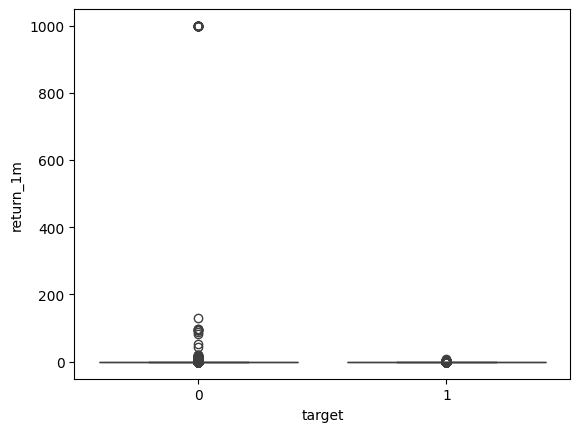

In [31]:
sample = (
    df.select(
        ["target", "return_1m"],      
    )
    .sample(
        n=100000,
        seed=42
    )
    .to_pandas()
)

sns.boxplot(
    data=sample,
    x="target",
    y="return_1m"
)

plt.show()


1. **Evidência de Outliers Extremos:** É nítida a presença de uma quebra de consistência matemática no regime de target=0, evidenciada pelo outlier posicionado no patamar de `1000`. Numericamente, este valor representa uma valorização absurda de 100.000% em 60 segundos, o que configura uma distorção decorrente de indeterminação matemática (divisão por preços iniciais nulos ou próximos de zero).
2. **Esmagamento Escalar da Distribuição:** Devido à magnitude desse outlier na escala do eixo vertical, a verdadeira variação interquartil de ambos os targets encontra-se visualmente comprimida próxima a `0.0`. Isto reitera que a volatilidade real do dia a dia é muito baixa.
3. **Justificativa de Data Cleaning:** Este gráfico valida matematicamente a necessidade de realizarmos um processo de *clipping* ou filtragem (remoção de instâncias com retornos fora de limites comerciais plausíveis, ex: acima de 50% ou abaixo de -50%) na etapa de pré-processamento, blindando os algoritmos de classificação contra vieses de treinamento.

# Correlação entre amostras

In [32]:
sample_corr = (
    df.select(
        features + ["target"]
    )
    .sample(
        n=100000,
        seed=42
    )
    .to_pandas()
)

In [33]:
corr = sample_corr.corr()

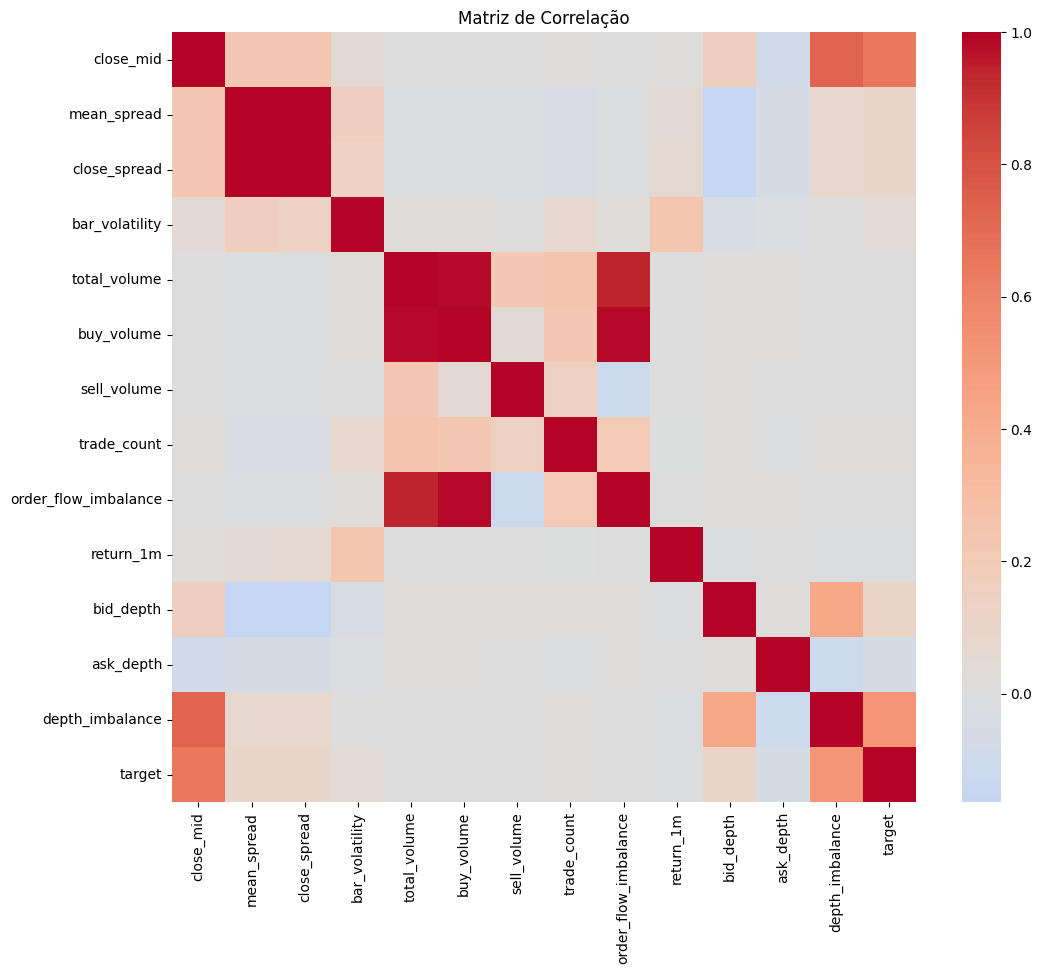

In [34]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlação")
plt.show()

A avaliação da matriz de correlação nos permite extrair insights estruturais sobre a colinearidade das features e sua relação com a variável dependente (`target`):

1. **Força Preditiva do Imbalance:** Confirmando as análises bivariadas anteriores, o `depth_imbalance` apresenta a maior correlação linear positiva com o `target` entre todas as features de microestrutura desenvolvidas, consolidando-se como a principal candidata a *feature importance* nos modelos preditivos.
2. **Multicolinearidade nos Volumes:** Observa-se um bloco de forte correlação positiva entre `total_volume`, `buy_volume` e `order_flow_imbalance`. Este comportamento é matematicamente esperado e serve de alerta para evitar redundâncias (multicolinearidade) em modelos lineares puros, justificando a preferência por modelos baseados em árvores de decisão.
3. **Dinâmica de Liquidez (Spread vs Depth):** A correlação negativa discreta (tom azulado) entre as variáveis de spread e o `bid_depth` valida a teoria microeconômica: à medida que a profundidade do livro de ofertas aumenta (maior liquidez), o custo de transação implicitado pelo spread tende a ser comprimido.

In [35]:
corr["target"].sort_values()

ask_depth              -0.058752
return_1m              -0.010443
sell_volume             0.001541
order_flow_imbalance    0.004803
buy_volume              0.005098
total_volume            0.005234
trade_count             0.013759
bar_volatility          0.045544
close_spread            0.091118
mean_spread             0.092764
bid_depth               0.116022
depth_imbalance         0.514100
close_mid               0.649636
target                  1.000000
Name: target, dtype: float64

O isolamento e ordenação dos coeficientes de correlação em relação ao `target` consolidam o processo de seleção inicial de features para a modelagem:

1. **Predomínio das Features de Preço e Profundidade:** O preço atual do contrato (`close_mid` em 0.65) e o desequilíbrio do livro de ordens (`depth_imbalance` em 0.51) apresentam forte associação linear positiva com a direção do preço nos 15 minutos subsequentes. Estatisticamente, estes números confirmam que o posicionamento prévio dos agentes nas filas de oferta carrega o maior teor informacional do dataset.
2. **Independência Linear dos Volumes:** As métricas de volume de agressão (`total_volume`, `buy_volume` e `order_flow_imbalance`) exibem coeficientes virtualmente nulos (~0.005) em uma perspectiva linear isolada. Isto indica que o volume atua de forma não-linear ou condicional (ex: dependendo do patamar de volatilidade), justificando o uso futuro de modelos não-lineares, como conjuntos de árvores de decisão.
3. **Consistência do Sentido Econômico:** A correlação negativa do `ask_depth` (-0.05) valida a premissa de que o acúmulo de liquidez na ponta de venda atua como uma barreira física de resistência, reduzindo a probabilidade de valorização do contrato no horizonte preditivo estipulado.

# Mercados mais líquidos

In [36]:
(
    df.group_by("market_id")
      .agg(
          pl.col("total_volume").sum()
      )
      .sort(
          "total_volume",
          descending=True
      )
      .head(10)
)

market_id,total_volume
str,f32
"""0xe492ad958b21201e928b66665708…",3.6908e6
"""0xf18253f5c0b0ffc42172a435892b…",3.5688e6
"""0xfc7fb7e4550f39b1a4059b233b33…",3349585.5
"""0xb70468bb7e635f836a72ae302c1e…",1.9008e6
"""0xabe1486b141aac413c96286eb3e4…",1646303.5
"""0xc6c7ccbb4d0e7d0ee813522f4063…",1.5459e6
"""0xca79771f582632406946bea87d59…",1.4612e6
"""0x9fc89f8e8bc61a232451064d15a3…",1.4608e6
"""0x31743c7bb0f88d9399e67cb1b553…",1.3525e6


# Como os preços se distribuem 

In [50]:
df.select(
    [
        pl.col("close_mid").min().alias("min"),
        pl.col("close_mid").quantile(0.25).alias("p25"),
        pl.col("close_mid").median().alias("median"),
        pl.col("close_mid").quantile(0.75).alias("p75"),
        pl.col("close_mid").max().alias("max")
    ]
)

min,p25,median,p75,max
f32,f32,f32,f32,f32
0.0005,0.0155,0.205,0.435,0.9995


1. Assimetria Severa e a Dinâmica de Múltiplas Escolhas
O dado mais marcante é que a **mediana está em `0.205`** e o **percentil 75% está em `0.435`**. Isso prova que a esmagadora maioria dos dados (mais de 75%) é composta por contratos "baratos", que custam menos da metade de um dólar. 

Esse padrão ocorre porque a Polymarket se baseia em mercados de múltiplas respostas (ex: *"Qual partido ganhará o controle do Senado?"* ou *"Quem vencerá o campeonato?"*). Como apenas uma única alternativa pode vencer (e expirar valendo \$1.00), todas as outras dezenas de opções perdedoras vão minguando em direção a zero, gerando essa enorme massa de dados concentrada em preços baixos.

2. Respeito Rigoroso aos Limites Financeiros
Os valores extremos de `0.0005` (mínimo) e `0.9995` (máximo) confirmam que o ecossistema do seu dataset respeita a barreira matemática da plataforma. Na Polymarket, um contrato nunca chega a valer exatamente 0 ou 1 dólar enquanto o mercado estiver aberto para negociação, pois sempre há uma fração residual de risco ou especulação antes do resultado oficial.

3. Impacto Crítico na Modelagem (O Peso do Preço)
Essa distribuição concentrada no chão explica por que a variável `close_mid` apresentou uma correlação linear tão alta de **`0.6496`** com o `target` no seu ranking anterior. 

Contratos que conseguem romper a barreira do "marasmo" e sobem além do patamar comum dos \$0,20 ou \$0,43 entram em um regime de momentum (tendência de alta), onde a probabilidade implícita do evento cresce e atrai mais investidores. O modelo de Machine Learning vai usar o preço atual como um forte balizador de regime para saber se está lidando com uma aposta altamente especulativa (perto de zero) ou com uma tendência consolidada de vitória.

<Figure size 800x400 with 0 Axes>

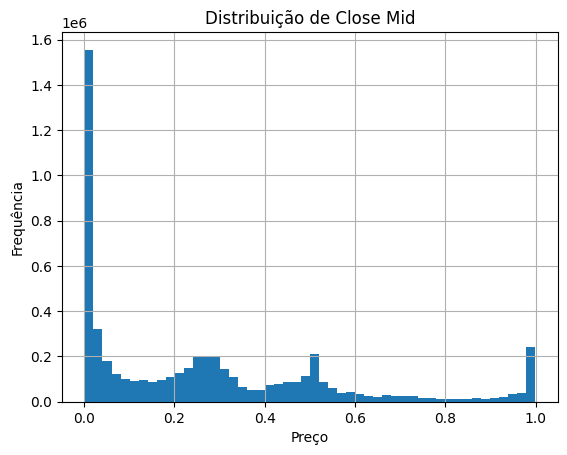

In [49]:
plt.figure(figsize=(8,4))

df.select(
    "close_mid"
).to_pandas().hist(
    bins=50
)

plt.title("Distribuição de Close Mid")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.show()

O histograma da variável `close_mid` mapeia de forma visual as probabilidades implícitas dos mercados preditivos da Polymarket, revelando uma distribuição multimodal fascinante:

1. **Predomínio de Contratos de Baixa Probabilidade:** O pico massivo adjacente ao patamar de `0.0` comprova a estrutura de mercados de escolha múltipla da plataforma. Como dezenas de alternativas colapsam para zero enquanto apenas uma vence, a base de dados acumula uma densidade esmagadora de "azarões" precificados em frações de centavos.
2. **Concentração Especulativa (Região de 0.20 a 0.35):** A formação de uma segunda ondulação bem distribuída nesta faixa reflete o comportamento típico de ativos de risco moderado com múltiplos concorrentes viáveis, patamar onde o balanço entre custo do bilhete e retorno atrai liquidez.
3. **Efeito Cara-ou-Coroa (Agulha em 0.50):** O pico isolado exatamente na marca de 50% traduz as situações de incerteza simétrica máxima em mercados binários (Sim/Não), registrando os períodos em que o consenso de mercado está perfeitamente dividido.
4. **Acúmulo de Resolução (Pico em 1.0):** A elevação na cauda direita ilustra a fase de convergência, onde o fato real está consolidado e o contrato caminha para a liquidação final, acumulando minutos de negociação em patamares de certeza estatística.

<Figure size 800x400 with 0 Axes>

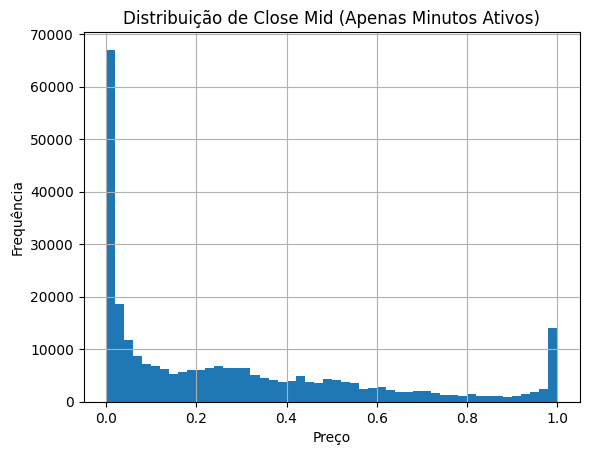

In [51]:
plt.figure(figsize=(8,4))

df.filter(
    pl.col("total_volume") > 0
).select(
    "close_mid"
).to_pandas().hist(
    bins=50
)

plt.title("Distribuição de Close Mid (Apenas Minutos Ativos)")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.show()

A aplicação do filtro de atividade (isolando apenas as barras de 1 minuto com transações efetivas) revela a verdadeira dinâmica de preços da microestrutura do Polymarket, eliminando os ruídos de inércia do ecossistema:

1. **Atenuação do Viés de Iliquidez:** O pico monumental anteriormente observado próximo a `0.0` sofreu uma redução drástica de escala. Isto demonstra que a massiva concentração no chão da distribuição era composta por ordens estáticas de mercados abandonados, e não por negociações contínuas.
2. **Suavização do Efeito de Equilíbrio (0.50):** A remoção do pico isolado no patamar de 50% confirma que os mercados em situação de "cara ou coroa" geram longos períodos de espera sem trades. Sob atividade, a transição de preços nessa zona intermediária ocorre de forma contínua e estocástica.
3. **Resiliência do Fluxo de Arbitragem (Pico em 1.0):** Ao contrário das outras anomalias, o acúmulo de dados na extremidade direita permaneceu proeminente. Economicamente, isto valida a existência de forte atividade de trading na reta final dos contratos (arbitragem de alta certeza), onde grandes volumes são movimentados para capturar frações finais de centavos antes da liquidação do mercado.

<Axes: >

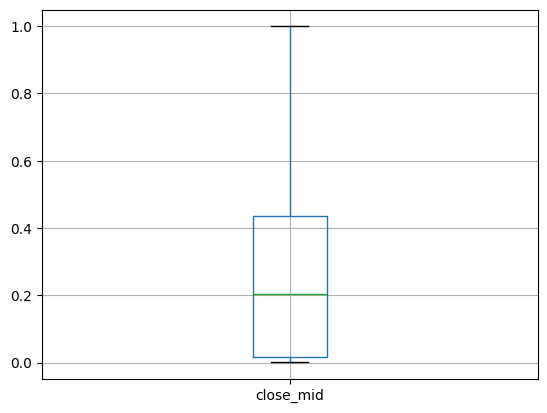

In [52]:
df.select(
    pl.col("close_mid")
).to_pandas().boxplot()

O gráfico de Boxplot para a variável `close_mid` solidifica as observações quantílicas e traz insights importantes sobre a distribuição de probabilidade implícita do ecossistema:

1. **Assimetria Positiva Evidente:** A concentração da caixa interquartil (IQR) na metade inferior do gráfico demonstra visualmente o viés de cauda longa à direita. A linha mediana (em verde) posicionada na faixa de `0.20` corrobora que o volume temporal de dados é dominado por situações onde os eventos possuem baixa probabilidade estimada de ocorrência.
2. **Dispersão na Zona de Favoritismo:** O *whisker* (antena) superior alongado denota que, embora existam menos dados na faixa de `0.45` a `1.0`, os preços se distribuem de forma contínua e espaçada à medida que os contratos caminham para a convergência e vitória.
3. **Estabilidade de Limites (Sem Outliers):** A inexistência de pontos plotados além dos limites dos *whiskers* valida a integridade matemática do dataset. Os dados comportam-se de forma estritamente confinada no intervalo $[0, 1]$, refletindo os limites operacionais de pagamento da própria estrutura de contratos da Polymarket.

In [53]:
df.group_by("target").agg(
    pl.mean("close_mid").alias("avg_price")
)

target,avg_price
i8,f32
1,0.566574
0,0.154589


# Como o spread se comporta? 


<Figure size 800x400 with 0 Axes>

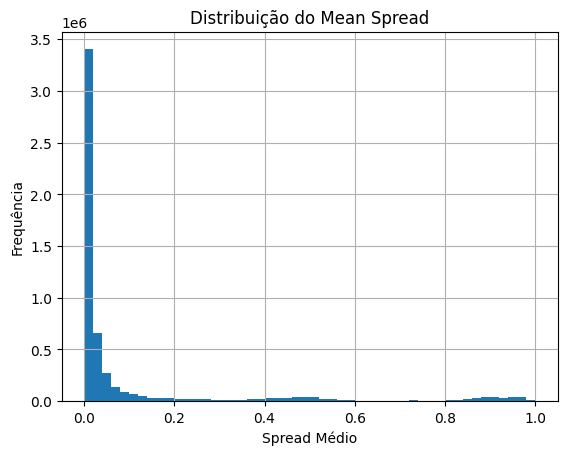

In [54]:
plt.figure(figsize=(8,4))

df.select(
    "mean_spread"
).to_pandas().hist(
    bins=50
)

plt.title("Distribuição do Mean Spread")
plt.xlabel("Spread Médio")
plt.ylabel("Frequência")
plt.show()

O comportamento do `mean_spread` atua como o principal termômetro de liquidez e custo de fricção operacional dentro do ecossistema mapeado:

1. **Predominância de Alta Liquidez e Eficiência:** O pico hiper-concentrado na vizinhança de `0.0` a `0.05` comprova que a maior fatia temporal do dataset monitora mercados maduros e eficientes. Nestes cenários, a atividade dos formadores de mercado mantém as ordens de compra (*bids*) e venda (*asks*) fortemente emparelhadas, minimizando os custos de execução para os traders.
2. **Identificação de Regimes de Iliquidez Crônica:** A cauda longa que se estende pela região central do gráfico (com pequenas elevações nas proximidades de `0.50`) denota minutos específicos onde o livro de ofertas sofre esvaziamento. Em termos de modelagem, spreads elevados servem como fortes sinalizadores de risco, indicando que qualquer agressão isolada de volume pode deslocar o preço de forma violenta devido à falta de contraparte próxima.
3. **Anomalia de Encerramento (Spread em 1.0):** O volume residual acumulado no limite superior absoluto traduz o colapso do livro nas fases finais de resolução do contrato. Quando o resultado de um mercado torna-se deterministicamente óbvio, uma das pontas de negociação deixa de existir, empurrando o spread para o teto regulatório da plataforma.

In [55]:
df.select(
    [
        pl.col("mean_spread").min().alias("min"),
        pl.col("mean_spread").quantile(0.25).alias("p25"),
        pl.col("mean_spread").median().alias("median"),
        pl.col("mean_spread").quantile(0.75).alias("p75"),
        pl.col("mean_spread").max().alias("max")
    ]
)

min,p25,median,p75,max
f32,f32,f32,f32,f32
0.000667,0.005,0.015,0.05,1.0


<Figure size 800x400 with 0 Axes>

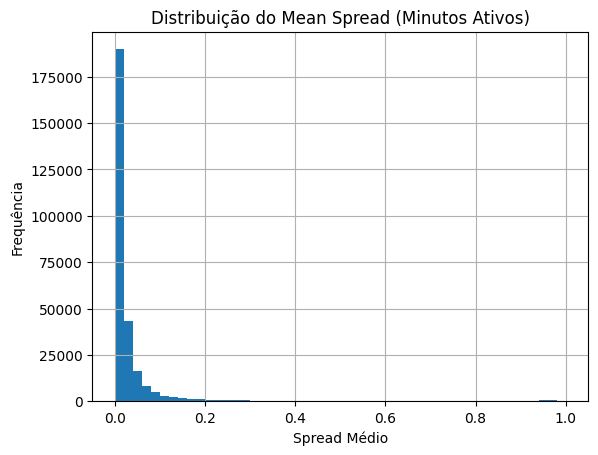

In [56]:
plt.figure(figsize=(8,4))

df.filter(
    pl.col("total_volume") > 0
).select(
    "mean_spread"
).to_pandas().hist(
    bins=50
)

plt.title("Distribuição do Mean Spread (Minutos Ativos)")
plt.xlabel("Spread Médio")
plt.ylabel("Frequência")
plt.show()

A análise visual do `mean_spread` restrito aos intervalos de tempo com atividade de trading revela uma distribuição exponencial altamente limpa, sanando distorções estruturais observadas no dataset bruto:

1. **Eliminação de Ruídos de Iliquidez:** O esvaziamento completo da região central do histograma (zona de `0.40` a `0.60`) e a quase extinção do acúmulo residual no limite de `1.0` demonstram que spreads excessivos eram assinaturas exclusivas de minutos estáticos e sem contraparte.
2. **Convergência para a Eficiência Microestrutural:** Sob o regime de atividade real, a cauda da distribuição decai rapidamente e se extingue por completo por volta de `0.25` a `0.30`. Isso comprova que a dinâmica de negociação efetiva força o pareamento constante entre compradores e vendedores, mantendo os custos de fricção severamente controlados.
3. **Ganho de Qualidade para Modelagem:** A transformação do recurso em uma curva de decaimento suave e previsível beneficia diretamente os modelos baseados em árvores e Redes Neurais, reduzindo a variância causada por outliers artificiais de APIs e permitindo uma associação mais robusta entre spreads saudáveis e a direção futura dos preços (`target`).

<Figure size 800x400 with 0 Axes>

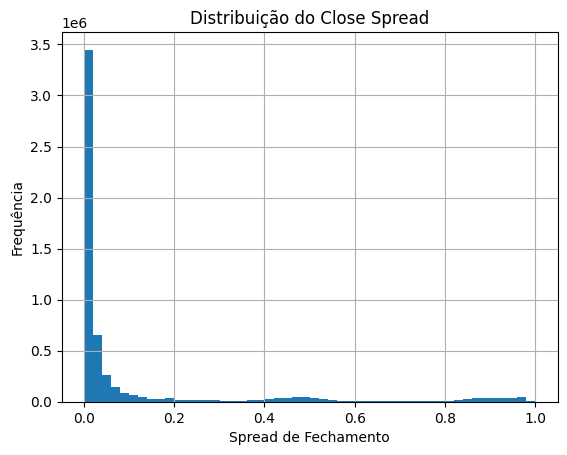

In [57]:
plt.figure(figsize=(8,4))

df.select(
    "close_spread"
).to_pandas().hist(
    bins=50
)

plt.title("Distribuição do Close Spread")
plt.xlabel("Spread de Fechamento")
plt.ylabel("Frequência")
plt.show()

O histograma da variável `close_spread` mapeia a eficiência do livro de ofertas no último segundo de cada intervalo amostral, servindo como um indicador de risco de execução instantânea:

1. **Estabilidade de Liquidez no Fechamento:** A dominância massiva do primeiro bin de dados (espremido entre `0.0` e `0.05`) reitera que o mecanismo de consenso de preços encerra a maioria dos blocos temporais em estado de alta eficiência e concorrência ativa.
2. **Persistência de Gaps Simétricos (Região de 0.50):** A sutil ondulação na faixa central evidencia a presença de spreads estruturais em mercados de menor apelo comercial, onde as pontas de compra e venda permanecem estaticamente afastadas no fechamento do minuto.
3. **Platô de Desabastecimento de Cauda Direita:** Diferente das métricas suavizadas por médias, o spread instantâneo de fechamento captura com maior sensibilidade o esvaziamento abrupto do livro na vizinhança de `1.0`. Este comportamento descreve minutos que encerraram em regime de estresse de liquidez ou abandono de ordens antes da virada do bloco.